<div style="text-align: right;">
  <img src="Logo_UNSAM.png" width="250">
</div>

Analisis y Procesamiento de Señales

# TS7: Filtrado digital lineal de ECG

## Estudiante: Mercedes López Gil Dillon

Para el siguiente trabajo práctico, buscamos generar distintos tipos de filtros digitales (dos filtros FIR y dos IIR), que posteriormente aplicaremos en una señal que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, donde buscaremos mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

Para esto, comenzaremos estableciendo una plantilla de diseño necesaria para que la señal de ECG se asemeje a los latidos promedio en cuanto a  suavidad de los trazos y nivel isoeléctrico nulo, ayudandonos de la información obtenida el la TS5 al trabajar con esta misma señal.

Luego de esto, diseñaremos los filtros anteriormente mencionados, verificando su respuesta en frecuencia en comparación con la plantilla de diseño establecida.

Por último, evaluaremos el rendimiento de estos filtros, verificando que este filtra las señales interferentes, y a su vez es inocuo en las zonas donde no haya interferencias.


## Parte 1: Diseño de plantilla

Utilizando los resultados obtenidos en la TS5 y siendo esto complementado con lo discutido durante las clases de esta materia, se llegó a la conclusión de que la plantilla debería ser de la siguiente forma:

- Banda de paso: de 0.5 a 35 Hz
- Banda de stop primera: de 0 a 0.1 Hz
- Banda de stop segunda: de 45 a fs/2 Hz

Esto se debe a que, a pesar de que estaremos perdiendo un poco de información (particularmente en frecuencias bajas), también estaríamos filtrando la mayor parte del ruido y dejando la señal casi intacta luego del filtrado.

Además, los valores de atenuación máxima deben ser de 1Hz, para evitar lo más posible la distorsión de la señal en la banda de paso, y los valores de atenuación mínima deben ser de 40Hz en la banda de stop, lo que nos permite un buen margen y asegura que todo el ruido dentro de la banda de stop esté lo suficientemente filtrado y que no afectará la señal.

## Parte 2a: Diseño de filtros tipo IIR

In [2]:
import numpy as np
from scipy import signal as sig

from scipy.signal import kaiserord

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write

import os

Debido a la manera en que se general los filtros IIR, generaremos ambos filtros a la vez, para posteriormente compararlos entre ellos y con la señal original. 

Los tipos de filtro a utilizar serán los siguientes: 

- Filtro Butterworth: es el de máxima planicidad, suele ser el que peor atenua pero a cambio te otorga un filtrado lineal.
- Filtro Cauer: requiere menos costo computacional, pero a cambio el filtrado en lugar de ser lineal tiene saltos.

In [3]:
ws1 = 0.1
wp1 = .5
wp2 = 35
ws2 = 45
gpass = 1 #dB
gstop = 40 #dB
wp = [wp1, wp2]
ws = [ws1, ws2]
fs = 1000

sos_coef_ff_but = sig.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='butter', output='sos', fs=fs)
sos_coef_ff_cauer = sig.iirdesign(wp, ws, gpass/2, gstop/2, analog=False, ftype='cauer', output='sos', fs=fs)


La razón por la que utilizamos las atenuaciones por la mitad (gpass/2 y gstop/2) es debido a la manera en que se aplicará el filtro a la señal posteriormente, ya que se aplicará dos veces el filtro lo que implica que el doble de atenuación.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9312\3293842279.py:18: RuntimeWarning: divide by zero encountered in log
  ax1.plot(omega_but, 20*np.log(abs(resp_freq_but)), 'C0', label=f'Butterworth de {taps_but} taps')


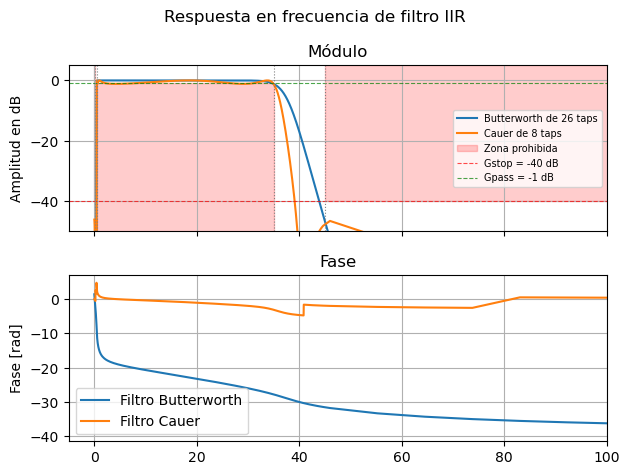

In [4]:
ww = np.concatenate([np.logspace(start=-2, stop= 0.1, num = 500), # puntos a evaluar en frecuencia, nos permite ver con mayor claridad ciertas partes
              np.linspace(start=1.26, stop= 35, num = 200),
              np.logspace(start= 1.55, stop =1.65, num= 300),
              np.linspace(start=46, stop= fs//2, num= 50)])


taps_but = sos_coef_ff_but.shape[0]*2 #orden del filtro
omega_but, resp_freq_but = sig.sosfreqz(sos_coef_ff_but, worN=ww, fs=fs)

taps_cauer = sos_coef_ff_cauer.shape[0]*2 #orden del filtro
omega_cauer, resp_freq_cauer = sig.sosfreqz(sos_coef_ff_cauer, worN=ww, fs=fs)


fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
fig.suptitle("Respuesta en frecuencia de filtro IIR")
ax1.set_title("Módulo")
ax1.plot(omega_but, 20*np.log(abs(resp_freq_but)), 'C0', label=f'Butterworth de {taps_but} taps')
ax1.plot(omega_cauer, 20*np.log(abs(resp_freq_cauer)), 'C1', label=f'Cauer de {taps_cauer} taps')
ax1.set_ylabel("Amplitud en dB")
ax1.set( xlim=(-5, 100), ylim=(-50, 5))
ax1.grid(True)

#Diseño de la plantilla

ymin = -40
ymin2 = -100
ymax = 5

# Banda de stop izquierda: 0 -> ws1  (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([0, ws1],       [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2, label='Zona prohibida')

# Banda de paso: wp1 -> wp2          (prohibido estar POR DEBAJO de -gpass)
ax1.fill_between([wp1, wp2],     [ymin2,   ymin2],   [-gpass, -gpass], color='red', alpha=0.2)

# Banda de stop derecha: ws2 -> fs/2 (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([ws2, fs/2],    [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2)

# Líneas de referencia
ax1.axhline(-gstop, color='red',   linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gstop = -{gstop} dB')
ax1.axhline(-gpass, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gpass = -{gpass} dB')
ax1.axvline(ws1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp2, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(ws2, color='gray', linestyle=':', linewidth=0.8)
ax1.legend(fontsize=7)

phase_but = np.unwrap(np.angle(resp_freq_but))
phase_cauer = np.unwrap(np.angle(resp_freq_cauer))
ax2.set_title("Fase")
ax2.plot(omega_but, phase_but, 'C0', label='Filtro Butterworth')
ax2.plot(omega_cauer, phase_cauer, 'C1', label='Filtro Cauer')
ax2.set_ylabel('Fase [rad]')
ax2.set_xlim(-5, 100)
ax2.grid(True)
ax2.legend()
plt.show()

Podemos ver claramente la diferencia entre la respuesta de ambos filtros, siendo la respuesta de Butterworth mucho mas lisa que la de Cauer, pero por otro lado si observamos la cantidad de taps que tiene cada una notaremos una gran diferencia. Al estar calculando utilizando secuencias de segundo orden (SOS por sus siglas en inglés), cada tap representa 2 ordenes de magnitud, siendo en el caso del Butter un filtro de orden 52 y en el caso de Cauer un filtro de orden 16 (notablemente menor).

Teniendo listos los filtros, lo probamos en la señal.

In [5]:
#importo la señal del ECG

carpeta_script_ecg_cr = os.getcwd()
ruta_archivo_ecg_cr = os.path.join(carpeta_script_ecg_cr, 'ECG_TP4.mat')
datos = sio.loadmat(ruta_archivo_ecg_cr)
ecg_one_lead_cr = datos['ecg_lead'].flatten()


N_ecg_cr = len(ecg_one_lead_cr)

ecg_cr = np.reshape(ecg_one_lead_cr , (1, N_ecg_cr))

Evaluamos sobre regiones de interés en particular dadas anteriormente por el profesor, que nos permitirán comparar tanto regiones sin ruido como regiones con ruido.

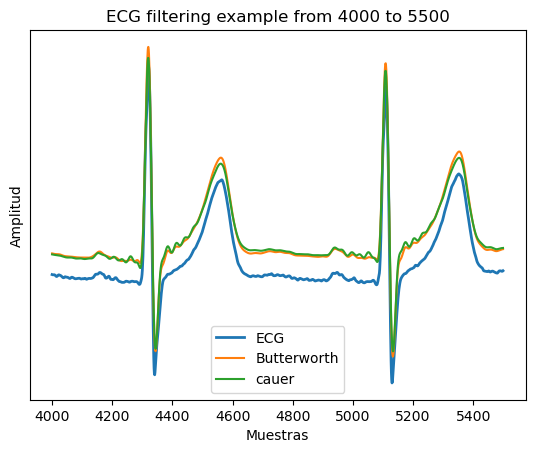

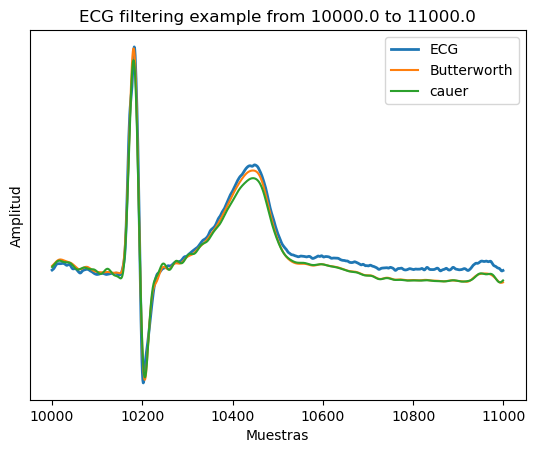

In [6]:
yy_ff_but = sig.sosfiltfilt(sos_coef_ff_but, ecg_cr)
yy_ff_cauer = sig.sosfiltfilt(sos_coef_ff_cauer, ecg_cr)

#REGIONES DE INTERÉS SIN RUIDO

regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N_ecg_cr , ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_cr[0, zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, yy_ff_but[0, zoom_region], label='Butterworth')
    plt.plot(zoom_region, yy_ff_cauer[0, zoom_region], label='cauer')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Amplitud')
    plt.xlabel('Muestras')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

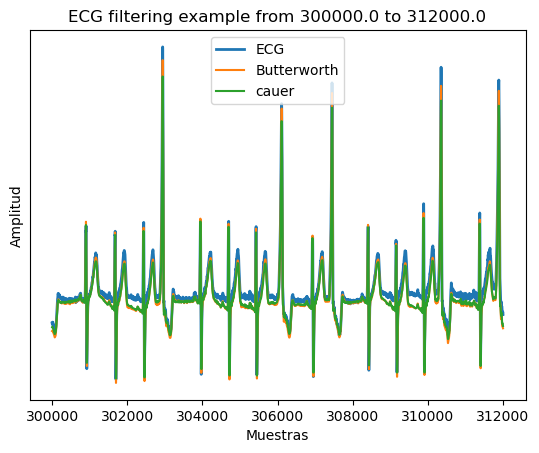

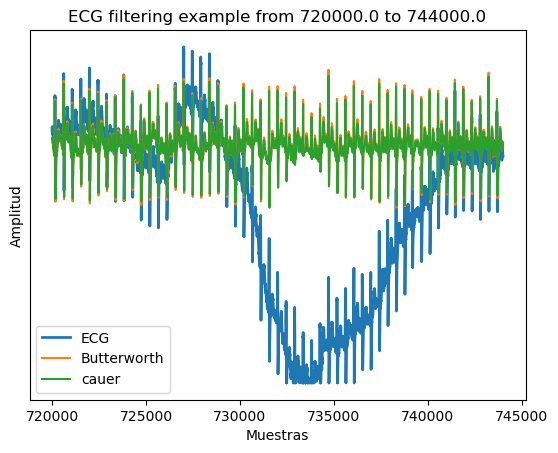

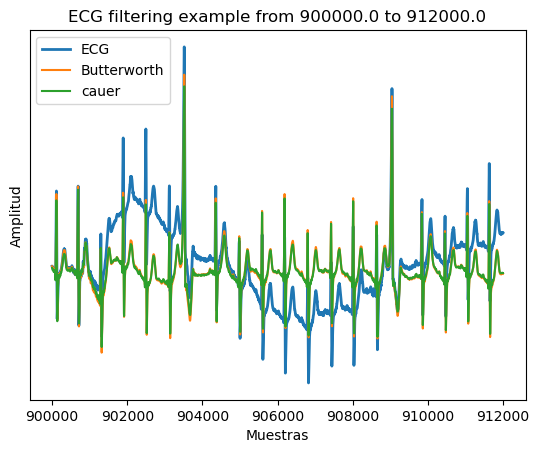

In [7]:
#REGIONES DE INTERES CON RUIDO 
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N_ecg_cr , ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_cr[0,zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, yy_ff_but[0, zoom_region], label='Butterworth')
    plt.plot(zoom_region, yy_ff_cauer[0, zoom_region], label='cauer')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Amplitud')
    plt.xlabel('Muestras')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

Como podemos observar, en el caso de las regiones sin ruido, las señales filtradas como la original están muy parecidas, en cambio para el caso de las regiones donde hay ruido, podemos ver que la señal filtrada corrige ese ruido que se observa en la original.

Notamos además como no hay mayor diferencia entre el filtro de Butter y el de Cauer realizados.

## Parte 2b: Diseño de filtros de tipo FIR

En el caso de los filtros FIR, la realización de cada filtro requiere su diseño en particular, por lo que en este caso cada filtro FIR se realizará por separado.

Es importante notar que los filtros FIR, al no ser retroalimentados requieren una cantidad de coeficientes mucho mayor a los filtros IIR, por lo que en este apartado del trabajo se verán distintos metodos usados para intentar mejorar la respuesta del filtro de una manera que no genere un gasto computacional tan grande.

Primer filtro FIR: Método de ventanas

In [12]:
numtaps = 1001 
#se utiliza la mitad de taps queridos ya que el tipo de filtro que usaremos en este caso es antisimetrico
#lo que implica que su respuesta queda invertida y debe pasarse dos veces para obtener la respuesta esperada.

ws1 = 0.25
wp1 = .3
wp2 = 36
ws2 = 39

trans_freq = np.linspace(ws1, wp1, 1001)
trans_gain = np.linspace(0, 1.011, 1001)**8.3  

trans_freq_high = np.linspace(wp2, ws2, 100)
trans_gain_high = 1 - np.linspace(0, 1, 100)**0.3

freq = np.concatenate([
    [0., ws1*.25, ws1*.5, ws1*.75],   
    trans_freq,
    trans_freq_high,[ fs/2]
])

gain = np.concatenate([
    [0., -2., -0.6, -0.1],
    trans_gain,
    trans_gain_high, [ 0.]
    ])

if numtaps % 2 == 0:
    gain[-1] = 0.

Se puede ver desde ahora tres de los metodos que se utilizarán para mejorar la respuesta en frecuencia de este filtro. 

En primer lugar vemos como los puntos seleccionados como frecuencias de paso y de corte no coinciden con las elegidas para la plantilla, esto se llama pre-distorción y consiste en pedirle al filtro una plantilla más exigente que la requerida para que la respuesta que se obtiene sea mejor.

Lo segundo es como se agregaron puntos intermedios además de los de la frecuencia de paso y corte, esto se hizo para ayudar a la interpolación que hace el filtro, mostrandole el tipo de transición que se busca de manera mucho mas precisa. Sirve además para forzar al filtro a ocupar mayor cantidad de los ordenes de los coeficientes en las transiciones por tener más puntos, haciendo que se enfoque más en estas que en otras partes del filtro.

La última es la utilización de gains negativos, esto unicamente se podrá utilizar en el metodo de ventanas, y nos permite forzar una respuesta más abrupta en las frecuencias no deseadas.

La razón de realizar todo esto es debido a lo mencionado anteriormente: los filtros FIR requieren un costo computacional mucho mayor a los vistos anteriormente, por lo que si no se realizasen estas cosas, se necesitarían por lo menos 5000 coeficientes para obtener la respuesta deseada.

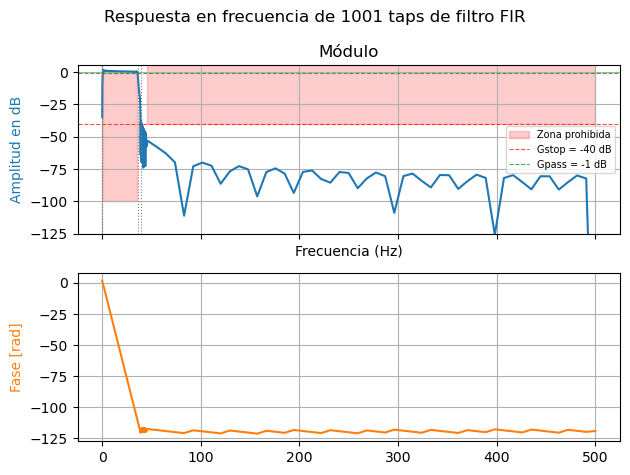

In [14]:
b_win = sig.firwin2(numtaps=numtaps, freq=freq, gain=gain, nfreqs = 2**14, window = 'boxcar', antisymmetric= True, fs=fs)
w_firwin, h_firwin = sig.freqz(b_win, worN=ww, fs=fs)

fig1, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs

fig1.suptitle(f"Respuesta en frecuencia de {numtaps} taps de filtro FIR")
ax1.set_title("Módulo")
ax1.plot(w, 20*np.log10(np.abs(h_firwin)), 'C0')
ax1.set_ylabel("Amplitud en dB", color='C0')
ax1.set(xlabel="Frecuencia (Hz)", xlim=(0, fs/2))
ax1.grid(True)

# --- Plantilla (zonas prohibidas en rojo) ---
ymin = -40
ymin2 = -100
ymax = 5

ws1_plantilla = .1
wp1_plantilla = .5
wp2_plantilla = 35
ws2_plantilla = 45

# Banda de stop izquierda: 0 -> ws1  (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([0, ws1_plantilla],       [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2, label='Zona prohibida')

# Banda de paso: wp1 -> wp2          (prohibido estar POR DEBAJO de -gpass)
ax1.fill_between([wp1_plantilla, wp2_plantilla],     [ymin2,   ymin2],   [-gpass, -gpass], color='red', alpha=0.2)

# Banda de stop derecha: ws2 -> fs/2 (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([ws2_plantilla, fs/2],    [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2)

# Líneas de referencia
ax1.axhline(-gstop, color='red',   linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gstop = -{gstop} dB')
ax1.axhline(-gpass, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gpass = -{gpass} dB')
ax1.axvline(ws1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp2, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(ws2, color='gray', linestyle=':', linewidth=0.8)
ax1.set_ylim(-125, 5)
ax1.legend(fontsize=7)

phase = np.unwrap(np.angle(h_firwin))
ax2.plot(w_firwin, phase, 'C1', label='Fase')
ax2.set_ylabel('Fase [rad]', color='C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

A pesar de que este filtro tiene una respuesta en frecuencia bastante buena (cumple la mayoría de los parametros impuestos en la plantilla), no logra terminar de cumplir con uno de estos: la atenuación a baja frecuencia de la banda de stop.

Luego de realizar múltiples ajustes, se determinó que la mejor respuesta posible, manteniendo el resto de los parámetros de la plantilla cumpliendose y para esta cantidad de coeficientes, es la conseguida.

La atenuación minima en la banda de stop es de 15dB, que luego de aplicarse dos veces el filtro resultaría en una atenuación de 30dB.

A continuación se mostrará lo recién discutido ampliando la visualización del filtro.

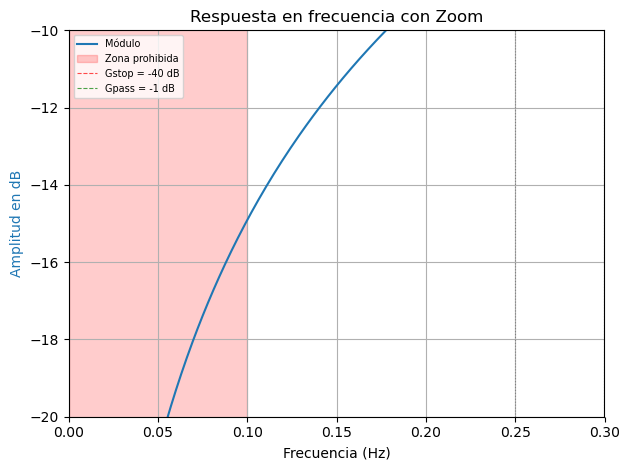

In [15]:
fig1, ax1 = plt.subplots(nrows=1, ncols=1, sharex=True, tight_layout=True)


ax1.set_title("Respuesta en frecuencia con Zoom")
ax1.plot(w, 20*np.log10(np.abs(h_firwin)), 'C0', label='Módulo')
ax1.set_ylabel("Amplitud en dB", color='C0')
ax1.set(xlabel="Frecuencia (Hz)", xlim=(0, fs/2))
ax1.grid(True)

# --- Plantilla (zonas prohibidas en rojo) ---
ymin = -40
ymin2 = -100
ymax = 5

ws1_plantilla = .1
wp1_plantilla = .5
wp2_plantilla = 35
ws2_plantilla = 45

# Banda de stop izquierda: 0 -> ws1  (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([0, ws1_plantilla],       [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2, label='Zona prohibida')

# Banda de paso: wp1 -> wp2          (prohibido estar POR DEBAJO de -gpass)
ax1.fill_between([wp1_plantilla, wp2_plantilla],     [ymin2,   ymin2],   [-gpass, -gpass], color='red', alpha=0.2)

# Banda de stop derecha: ws2 -> fs/2 (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([ws2_plantilla, fs/2],    [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2)

# Líneas de referencia
ax1.axhline(-gstop, color='red',   linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gstop = -{gstop} dB')
ax1.axhline(-gpass, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gpass = -{gpass} dB')
ax1.axvline(ws1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp2, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(ws2, color='gray', linestyle=':', linewidth=0.8)
ax1.set_xlim(0, 0.3)
ax1.set_ylim(-20, -10)
ax1.legend(fontsize=7)
plt.show()

Segundo filtro FIR: método de cuadrados minimos.

A diferencia de los métodos utilizados para el filtro anterior, en el caso del método de cuadrados mínimos existe una variable dentro de la función llamada weight (peso) que nos permite determinar de manera simple y directa la cantidad de coeficientes que se utilizan para cada banda dentro del filtro, lo que nos permite darle mayor importancia (o peso) a a primer banda de transición, que es la más abrupta.

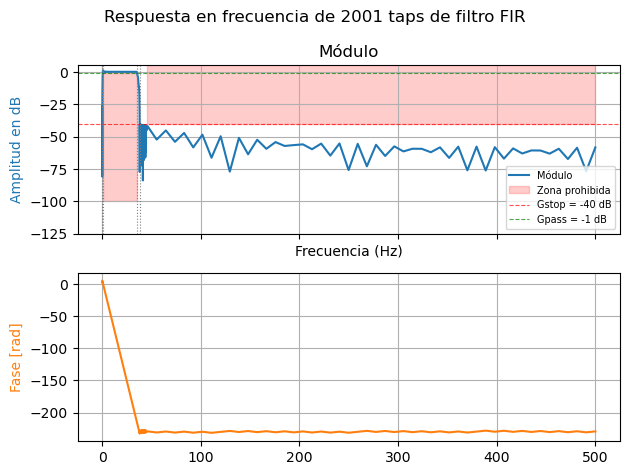

In [24]:
numtaps= 2001

ws1 = 0.18
wp1 = .5
wp2 = 35
ws2 = 38

ts_low  = np.linspace(ws1, wp1, 102)[1:-1]  
gs_low  = np.linspace(0, 1, 102)[1:-1]
ts_high = np.linspace(wp2, ws2, 102)[1:-1]
gs_high = np.linspace(1, 0, 102)[1:-1]

w_stop1  = 10000.   
w_stop2 = 1.
w_pass  = 100.    
w_trans1 = 0.05  
w_trans2 = 500.

freq    = np.concatenate([[0., ws1], ts_low, [wp1, wp2], ts_high, [ws2, fs/2]])
gain = np.concatenate([[0.,  0.], gs_low, [ 1.,  1.], gs_high, [ 0.,   0.]])


weight  = np.concatenate([[w_stop1], np.full(50, w_trans2), [w_pass], np.full(50, w_trans1), [w_stop2]])

ls_win = sig.firls(numtaps= numtaps, 
                   bands= freq, 
                   desired=gain, 
                   weight= weight,
                   fs= fs)


w_ls, h_ls = sig.freqz(ls_win, worN=ww, fs=fs)


fig1, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs

fig1.suptitle(f"Respuesta en frecuencia de {numtaps} taps de filtro FIR")
ax1.set_title("Módulo")
ax1.plot(w, 20*np.log10(np.abs(h_ls)), 'C0', label='Módulo')
ax1.set_ylabel("Amplitud en dB", color='C0')
ax1.set(xlabel="Frecuencia (Hz)", xlim=(0, fs/2))
ax1.grid(True)


ymin = -40
ymin2 = -100
ymax = 5

ws1_plantilla = .1
wp1_plantilla = .6
wp2_plantilla = 35
ws2_plantilla = 45

# Banda de stop izquierda: 0 -> ws1  (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([0, ws1_plantilla],       [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2, label='Zona prohibida')

# Banda de paso: wp1 -> wp2          (prohibido estar POR DEBAJO de -gpass)
ax1.fill_between([wp1_plantilla, wp2_plantilla],     [ymin2,   ymin2],   [-gpass, -gpass], color='red', alpha=0.2)

# Banda de stop derecha: ws2 -> fs/2 (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([ws2_plantilla, fs/2],    [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2)

# Líneas de referencia
ax1.axhline(-gstop, color='red',   linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gstop = -{gstop} dB')
ax1.axhline(-gpass, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gpass = -{gpass} dB')
ax1.axvline(ws1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp2, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(ws2, color='gray', linestyle=':', linewidth=0.8)
ax1.set_ylim(-125, 5)
ax1.legend(fontsize=7)

phase = np.unwrap(np.angle(h_ls))
ax2.plot(w_ls, phase, 'C1', label='Fase')
ax2.set_ylabel('Fase [rad]', color='C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()

Tal como lo ocurrido con el filtro Fir anterior, no fue posible encontrar una combinación adecuada de datos para que se cumpliera el filtro utilizando ~2000 coeficientes. Sin embargo, consideramos que este filtro es el que logra cumplir de la mejor manera posible los requisitos de la plantilla. A continuación haremos una ampliación para que se logre ver correctamente el punto en el que este filtro falla comparado con la plantilla diseñada.

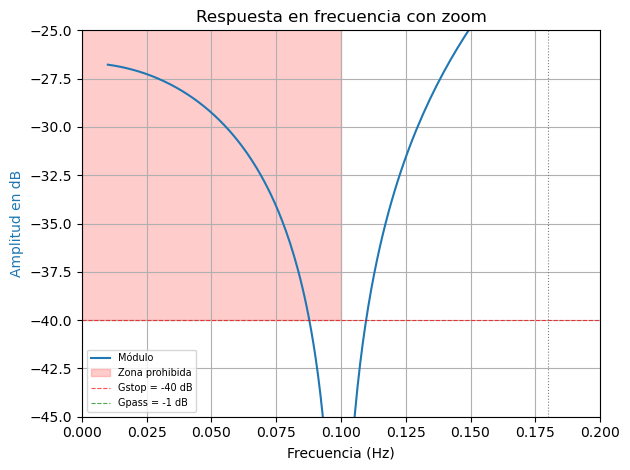

In [25]:
fig1, ax1 = plt.subplots(nrows=1, ncols=1, sharex=True, tight_layout=True)

ax1.set_title("Respuesta en frecuencia con zoom")
ax1.plot(w, 20*np.log10(np.abs(h_ls)), 'C0', label='Módulo')
ax1.set_ylabel("Amplitud en dB", color='C0')
ax1.set(xlabel="Frecuencia (Hz)", xlim=(0, fs/2))
ax1.grid(True)


ymin = -40
ymin2 = -100
ymax = 5

ws1_plantilla = .1
wp1_plantilla = .6
wp2_plantilla = 35
ws2_plantilla = 45

# Banda de stop izquierda: 0 -> ws1  (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([0, ws1_plantilla],       [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2, label='Zona prohibida')

# Banda de paso: wp1 -> wp2          (prohibido estar POR DEBAJO de -gpass)
ax1.fill_between([wp1_plantilla, wp2_plantilla],     [ymin2,   ymin2],   [-gpass, -gpass], color='red', alpha=0.2)

# Banda de stop derecha: ws2 -> fs/2 (prohibido estar POR ENCIMA de -gstop)
ax1.fill_between([ws2_plantilla, fs/2],    [ymin, ymin], [ymax,  ymax],  color='red', alpha=0.2)

# Líneas de referencia
ax1.axhline(-gstop, color='red',   linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gstop = -{gstop} dB')
ax1.axhline(-gpass, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label=f'Gpass = -{gpass} dB')
ax1.axvline(ws1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp1, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(wp2, color='gray', linestyle=':', linewidth=0.8)
ax1.axvline(ws2, color='gray', linestyle=':', linewidth=0.8)
ax1.set_xlim(0, 0.2)
ax1.set_ylim(-45, -25)
ax1.legend(fontsize=7)
plt.show()

Podemos ver como a pesar de que en la frecuencia de stop (ws1) se logra cumplir con la atenuación impuesta, luego de esto se genera un salto dentro de la banda de stop.

A pesar de que tanto el filtro FIR con el método de ventanas como el de el método de cuadrados mínimos no logran cumplir completamente la plantilla deseada, se considera que funcionan lo suficientemente bien según lo hablado durante las clases centradas al desarrollo de este trabajo. 

A continuación probaremos los dos filtros realizados en la señal del ECG utilizada anteriormente, lo que nos permitirá verificar que el filtro funcione como es esperado.

In [26]:
ECG_firwin = sig.filtfilt(b_win, 1., ecg_one_lead_cr)
ECG_ls = sig.filtfilt(ls_win, 1., ecg_one_lead_cr)

Verificamos dentro de las regiones de interes utilizadas anteriormente para poder corroborar que el filtro atenue las frecuencias no deseadas, y que sin embargo sea inocuo para las frecuencias de paso.

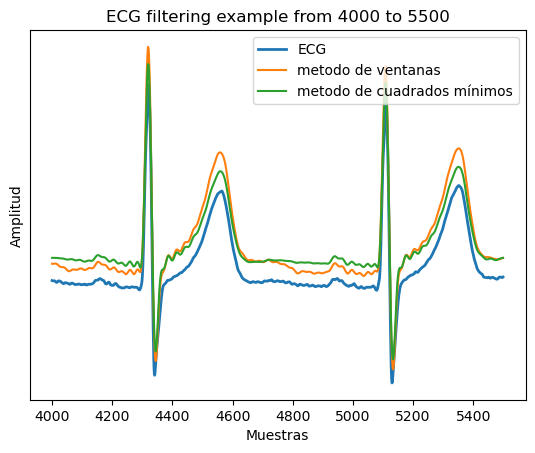

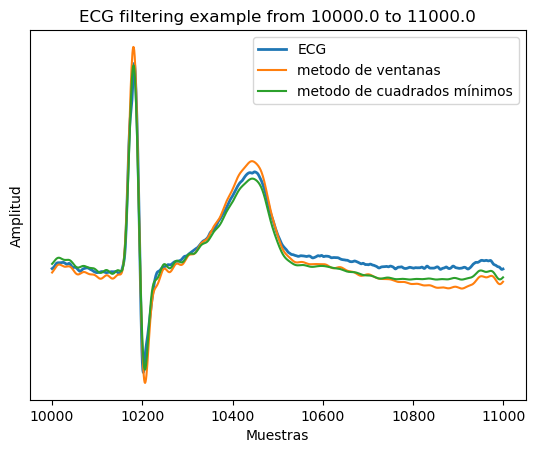

In [29]:
# Regiones de interés sin ruido 
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N_ecg_cr , ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_cr[0, zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_firwin[zoom_region], label = 'metodo de ventanas')
    plt.plot(zoom_region, ECG_ls[zoom_region], label = 'metodo de cuadrados mínimos')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Amplitud')
    plt.xlabel('Muestras')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

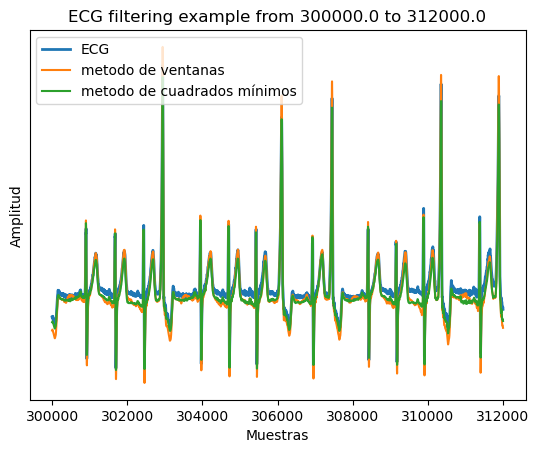

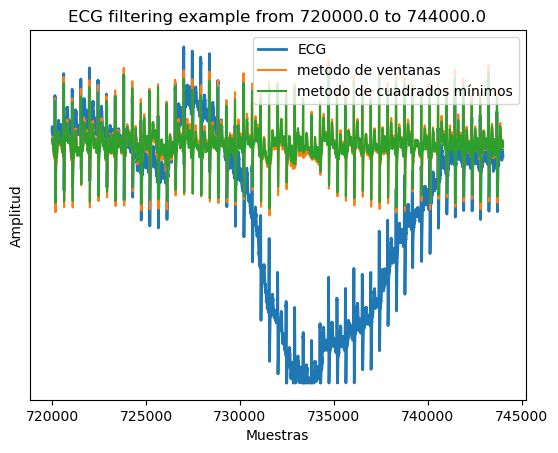

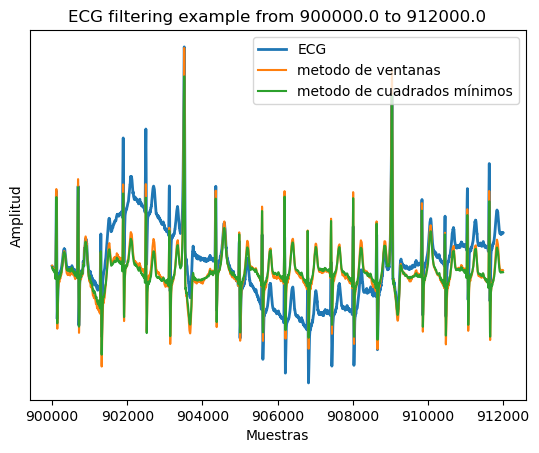

In [30]:
# Regiones de interés con ruido 
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N_ecg_cr , ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_cr[0,zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_firwin[zoom_region], label = 'metodo de ventanas')
    plt.plot(zoom_region, ECG_ls[zoom_region], label = 'metodo de cuadrados mínimos')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Amplitud')
    plt.xlabel('Muestras')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

Tal como se habia esperado, a pesar de que ninguno de los dos filtros logró cumplir por completo con los parametros deseados, al utilizarlo para el filtrado del ECG podemos ver que funcionan correctamente, siendo comparables incluso con los filtros realizados utilizando retroalimentación (filtros IIR, mostrados en la primer parte).

## Conclusión

A lo largo de este trabajo se diseñaron y evaluaron distintos tipos de filtros digitales con el objetivo de procesar una señal ECG, eliminando componentes de frecuencia no deseadas sin distorsionar las de interés clínico.

En primer lugar, se diseñó la plantilla de especificaciones a partir de datos previos, definiendo las bandas de paso y de stop con sus respectivas tolerancias. Sobre esta base se implementaron dos filtros IIR: uno de Butterworth y uno de Cauer. Ambos lograron cumplir con la plantilla y mostraron un comportamiento satisfactorio al ser aplicados sobre la señal ECG, atenuando correctamente las frecuencias no deseadas sin afectar visiblemente las de interés.

En cuanto a los filtros FIR, se trabajó con el método de ventanas mediante firwin2 y con el método de mínimos cuadrados mediante firls. En ambos casos se presentaron dificultades para cumplir simultáneamente todas las restricciones de la plantilla con un número razonable de coeficientes. Tras un proceso iterativo de ajuste de parámetros, pesos y especificaciones, se obtuvo la mejor respuesta en frecuencia posible para aproximadamente 2000 taps, valor acordado con el docente como límite práctico. Si bien ninguno de los dos filtros FIR logró satisfacer completamente la plantilla, al ser aplicados sobre la señal ECG demostraron ser funcionalmente adecuados, atenuando las componentes no deseadas y preservando las de interés de forma comparable a los filtros IIR.

Como conclusión general, todos los filtros diseñados resultaron aptos para el procesamiento de la señal ECG en la práctica, independientemente del cumplimiento estricto de la plantilla. Esto pone de manifiesto que las especificaciones de diseño son una guía para garantizar cierto comportamiento, pero la evaluación final del filtro debe hacerse siempre sobre la señal real que se desea procesar.